# Setup

In [56]:
from google.colab import drive
drive.mount('/content/drive')

import subprocess, sys

def pip_install(*pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *pkgs])

pip_install(
    "ultralytics",
    "scikit-learn",
    "matplotlib",
    "seaborn",
    "opencv-python-headless",
    "filterpy",
    "lap",
    "sahi",
    "PyYAML",
)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [57]:
import os, cv2, shutil, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from collections import defaultdict
from sklearn.model_selection import train_test_split
import yaml
import torch
from ultralytics import YOLO
from scipy.optimize import linear_sum_assignment
from filterpy.kalman import KalmanFilter
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction

ROOT_DIR        = '/content/drive/MyDrive/DriveIndia'
IMAGE_DIR       = f'{ROOT_DIR}/images'
LABEL_DIR       = f'{ROOT_DIR}/labels'
TRAIN_IMAGE_DIR = f'{IMAGE_DIR}/train'
VAL_IMAGE_DIR   = f'{IMAGE_DIR}/val'
TRAIN_LABEL_DIR = f'{LABEL_DIR}/train'
VAL_LABEL_DIR   = f'{LABEL_DIR}/val'
EXPERIMENT_DIR  = f'{ROOT_DIR}/driveindia_experiment'
TRACKING_DIR    = f'{ROOT_DIR}/tracking_results'
DATASET_YAML    = f'{ROOT_DIR}/dataset.yaml'
BEST_MODEL_PATH = f'{EXPERIMENT_DIR}/yolov8m_driveindia/weights/best.pt'

for d in [EXPERIMENT_DIR, TRACKING_DIR,
          TRAIN_IMAGE_DIR, VAL_IMAGE_DIR,
          TRAIN_LABEL_DIR, VAL_LABEL_DIR]:
    os.makedirs(d, exist_ok=True)

print(f"Root   : {ROOT_DIR}")
print(f"Images : {IMAGE_DIR}")
print(f"Labels : {LABEL_DIR}")


Root   : /content/drive/MyDrive/DriveIndia
Images : /content/drive/MyDrive/DriveIndia/images
Labels : /content/drive/MyDrive/DriveIndia/labels


In [58]:
RAW_CLASS_MAPPING = {
    '0':  'Person',

    '1':  'Bicycle',
    '2':  'Car',
    '3':  'Motorcycle',
    '4':  'Bus',
    '5':  'Commercial vehicle',
    '6':  'Truck',
    '7':  'Autorickshaw',
    '8':  'Ambulance',
    '9':  'Police vehicle',
    '10': 'Tractor',
    '11': 'Pushcart',
    '12': 'Construction vehicle',

    '13': 'Route board',
    '14': 'Traffic sign',
    '15': 'Traffic light',
    '16': 'Temporary traffic barrier',
    '17': 'Traffic cone',
    '18': 'Rumblestrips',
    '19': 'Unmarked speed bump',
    '20': 'Marked speed bump',
    '21': 'Zebra crossing',

    '22': 'Animal',
    '23': 'Pothole',
}

sorted_orig_ids  = sorted(RAW_CLASS_MAPPING.keys(), key=lambda x: int(x))
id_mapping       = {orig: str(new) for new, orig in enumerate(sorted_orig_ids)}
CLASS_NAMES      = [RAW_CLASS_MAPPING[oid] for oid in sorted_orig_ids]
NUM_CLASSES      = len(CLASS_NAMES)

SMALL_CLASSES = {
    'Bicycle', 'Motorcycle', 'Autorickshaw', 'Pushcart',
    'Traffic cone', 'Pothole', 'Person',
}
SMALL_CLASS_IDS = {i for i, n in enumerate(CLASS_NAMES) if n in SMALL_CLASSES}

print(f"\n✓ {NUM_CLASSES} classes configured")
for new_id, name in enumerate(CLASS_NAMES):
    tag = '⬡ small' if new_id in SMALL_CLASS_IDS else ''
    print(f"  {new_id:2d}: {name} {tag}")




✓ 24 classes configured
   0: Person ⬡ small
   1: Bicycle ⬡ small
   2: Car 
   3: Motorcycle ⬡ small
   4: Bus 
   5: Commercial vehicle 
   6: Truck 
   7: Autorickshaw ⬡ small
   8: Ambulance 
   9: Police vehicle 
  10: Tractor 
  11: Pushcart ⬡ small
  12: Construction vehicle 
  13: Route board 
  14: Traffic sign 
  15: Traffic light 
  16: Temporary traffic barrier 
  17: Traffic cone ⬡ small
  18: Rumblestrips 
  19: Unmarked speed bump 
  20: Marked speed bump 
  21: Zebra crossing 
  22: Animal 
  23: Pothole ⬡ small


In [59]:
valid_orig_ids  = set(RAW_CLASS_MAPPING.keys())
files_kept      = 0
files_removed   = 0
annotation_counts = defaultdict(int)

for label_file in os.listdir(LABEL_DIR):
    if not label_file.endswith('.txt'):
        continue

    file_path = os.path.join(LABEL_DIR, label_file)
    with open(file_path, 'r') as f:
        lines = f.readlines()

    new_lines = []
    for line in lines:
        parts = line.strip().split()
        if not parts:
            continue
        old_id = parts[0]
        if old_id in valid_orig_ids:
            parts[0] = id_mapping[old_id]
            new_lines.append(' '.join(parts))
            annotation_counts[int(parts[0])] += 1

    if new_lines:
        with open(file_path, 'w') as f:
            f.write('\n'.join(new_lines))
        files_kept += 1
    else:
        os.remove(file_path)
        files_removed += 1

print(f"\nLabel filtering complete:")
print(f"  Kept   : {files_kept} files")
print(f"  Removed: {files_removed} files (no matching annotations)")
print("\nAnnotation counts per class:")
for new_id, name in enumerate(CLASS_NAMES):
    cnt = annotation_counts.get(new_id, 0)
    print(f"  {new_id:2d} {name:<28}: {cnt:>6}")




Label filtering complete:
  Kept   : 0 files
  Removed: 0 files (no matching annotations)

Annotation counts per class:
   0 Person                      :      0
   1 Bicycle                     :      0
   2 Car                         :      0
   3 Motorcycle                  :      0
   4 Bus                         :      0
   5 Commercial vehicle          :      0
   6 Truck                       :      0
   7 Autorickshaw                :      0
   8 Ambulance                   :      0
   9 Police vehicle              :      0
  10 Tractor                     :      0
  11 Pushcart                    :      0
  12 Construction vehicle        :      0
  13 Route board                 :      0
  14 Traffic sign                :      0
  15 Traffic light               :      0
  16 Temporary traffic barrier   :      0
  17 Traffic cone                :      0
  18 Rumblestrips                :      0
  19 Unmarked speed bump         :      0
  20 Marked speed bump           :     

In [60]:
dataset_config = {
    'path' : ROOT_DIR,
    'train': 'images/train',
    'val'  : 'images/val',
    'nc'   : NUM_CLASSES,
    'names': CLASS_NAMES,
}

with open(DATASET_YAML, 'w') as f:
    yaml.dump(dataset_config, f, default_flow_style=False, allow_unicode=True)

print("dataset.yaml written:")
print(yaml.dump(dataset_config, default_flow_style=False))




dataset.yaml written:
names:
- Person
- Bicycle
- Car
- Motorcycle
- Bus
- Commercial vehicle
- Truck
- Autorickshaw
- Ambulance
- Police vehicle
- Tractor
- Pushcart
- Construction vehicle
- Route board
- Traffic sign
- Traffic light
- Temporary traffic barrier
- Traffic cone
- Rumblestrips
- Unmarked speed bump
- Marked speed bump
- Zebra crossing
- Animal
- Pothole
nc: 24
path: /content/drive/MyDrive/DriveIndia
train: images/train
val: images/val



In [61]:
import os
import sys

if not os.path.exists('/content/yolov9'):
    print("Cloning YOLOv9 repository...")
    !git clone https://github.com/WongKinYiu/yolov9.git
    !pip install -q -r /content/yolov9/requirements.txt
    !pip install -q seaborn tensorboard

sys.path.append('/content/yolov9')

print("✓ YOLOv9 repository ready")

Cloning YOLOv9 repository...
Cloning into 'yolov9'...
remote: Enumerating objects: 781, done.
remote: Total 781 (delta 0), reused 0 (delta 0), pack-reused 781 (from 1)
Receiving objects: 100% (781/781), 3.27 MiB | 6.46 MiB/s, done.
Resolving deltas: 100% (330/330), done.
✓ YOLOv9 repository ready


In [62]:
import os
import yaml

CUSTOM_HYP_PATH = f'{ROOT_DIR}/custom_hyp.yaml'

custom_hyp = {
    'lr0': 0.01,
    'lrf': 0.01,
    'momentum': 0.937,
    'weight_decay': 0.0005,
    'warmup_epochs': 3,
    'warmup_momentum': 0.8,
    'warmup_bias_lr': 0.1,

    'box': 7.5,
    'cls': 0.5,
    'dfl': 1.5,

    'hsv_h': 0.015,
    'hsv_s': 0.7,
    'hsv_v': 0.4,
    'degrees': 10.0,
    'translate': 0.2,
    'scale': 0.9,
    'shear': 0.0,
    'perspective': 0.0,
    'flipud': 0.0,
    'fliplr': 0.5,
    'mosaic': 1.0,
    'mixup': 0.15,
    'copy_paste': 0.3,

    # Additional required keys (YOLOv9 defaults)
    'cls_pw': 1.0,          # class loss weight
    'obj_pw': 1.0,          # object loss weight
    'iou_t': 0.20,          # IoU threshold for matching
    'anchor_t': 4.0,        # anchor target threshold
    'fl_gamma': 0.0,        # focal loss gamma (0 = no focal)
}

with open(CUSTOM_HYP_PATH, 'w') as f:
    yaml.dump(custom_hyp, f, default_flow_style=False)

print(f"✅ Complete hyp file created: {CUSTOM_HYP_PATH}")
print("\nContents:")
print(yaml.dump(custom_hyp, default_flow_style=False))

✅ Complete hyp file created: /content/drive/MyDrive/DriveIndia/custom_hyp.yaml

Contents:
anchor_t: 4.0
box: 7.5
cls: 0.5
cls_pw: 1.0
copy_paste: 0.3
degrees: 10.0
dfl: 1.5
fl_gamma: 0.0
fliplr: 0.5
flipud: 0.0
hsv_h: 0.015
hsv_s: 0.7
hsv_v: 0.4
iou_t: 0.2
lr0: 0.01
lrf: 0.01
mixup: 0.15
momentum: 0.937
mosaic: 1.0
obj_pw: 1.0
perspective: 0.0
scale: 0.9
shear: 0.0
translate: 0.2
warmup_bias_lr: 0.1
warmup_epochs: 3
warmup_momentum: 0.8
weight_decay: 0.0005



In [63]:
import os
import re

def patch_torch_load(filepath):
    """Replace torch.load(...) with weights_only=False in the given file."""
    if not os.path.exists(filepath):
        print(f"⚠️ File not found: {filepath}")
        return False

    with open(filepath, 'r') as f:
        content = f.read()

    pattern = r"torch\.load\(([^)]*)\)"

    def replacer(match):
        args = match.group(1)
        if 'weights_only' in args:
            return match.group(0)  # already fixed
        # If there are existing kwargs, add weights_only=False
        if '=' in args:
            return f"torch.load({args}, weights_only=False)"
        else:
            # If only positional args, append weights_only=False
            return f"torch.load({args}, weights_only=False)"

    new_content = re.sub(pattern, replacer, content)

    if new_content != content:
        with open(filepath, 'w') as f:
            f.write(new_content)
        print(f"✅ Patched: {filepath}")
        return True
    else:
        print(f"ℹ️ No change needed: {filepath}")
        return True

# Patch both files
patch_torch_load('/content/yolov9/train.py')
patch_torch_load('/content/yolov9/val.py')

✅ Patched: /content/yolov9/train.py
ℹ️ No change needed: /content/yolov9/val.py


True

In [64]:
# Create YOLOv9 dataset.yaml (separate from your existing one)
YOLOV9_DATASET_YAML = f'{ROOT_DIR}/yolov9_dataset.yaml'

yolov9_dataset_config = {
    'path': ROOT_DIR,
    'train': 'images/train',    # relative to path
    'val': 'images/val',        # relative to path
    'nc': len(CLASS_NAMES),
    'names': CLASS_NAMES,
}

import yaml
with open(YOLOV9_DATASET_YAML, 'w') as f:
    yaml.dump(yolov9_dataset_config, f, default_flow_style=False)

YOLOV9_EXPERIMENT_DIR = f'{EXPERIMENT_DIR}/yolov9_driveindia'


os.makedirs(YOLOV9_EXPERIMENT_DIR, exist_ok=True)


print(f"✓ YOLOv9 dataset config saved to: {YOLOV9_DATASET_YAML}")

✓ YOLOv9 dataset config saved to: /content/drive/MyDrive/DriveIndia/yolov9_dataset.yaml


In [65]:
if not os.path.exists('/content/yolov9/gelan-c.pt'):
    !cd /content/yolov9 && wget -O gelan-c.pt https://github.com/WongKinYiu/yolov9/releases/download/v0.1/gelan-c.pt

--2026-06-29 17:35:00--  https://github.com/WongKinYiu/yolov9/releases/download/v0.1/gelan-c.pt
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/759338070/f7cec348-8853-4218-a48a-1559f5088b19?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-06-29T18%3A19%3A50Z&rscd=attachment%3B+filename%3Dgelan-c.pt&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-06-29T17%3A18%3A57Z&ske=2026-06-29T18%3A19%3A50Z&sks=b&skv=2018-11-09&sig=ZoIbQXsIT6DFmjLzU%2BH8%2FoMv%2F4BTCCBWnnkajfJzB1g%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc4Mjc1NjMwMCwibmJmIjoxNzgyNzU0NTAwLCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ibG9iLmNvcm

# Training

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")
if device == 'cuda':
    print(f"GPU   : {torch.cuda.get_device_name(0)}")

model = YOLO('yolov8m.pt')

model.train(
    data           = DATASET_YAML,
    epochs         = 60,
    imgsz          = 640,
    batch          = 16,
    device         = 0 if device == 'cuda' else 'cpu',
    workers        = 8,
    patience       = 30,
    cos_lr         = True,
    lr0            = 0.01,
    lrf            = 0.01,
    momentum       = 0.937,
    weight_decay   = 0.0005,
    warmup_epochs  = 3,
    warmup_momentum= 0.8,
    warmup_bias_lr = 0.1,
    box            = 7.5,
    cls            = 0.5,
    dfl            = 1.5,
    hsv_h          = 0.015,
    hsv_s          = 0.7,
    hsv_v          = 0.4,
    degrees        = 10.0,
    translate      = 0.2,
    scale          = 0.9,
    flipud         = 0.0,
    fliplr         = 0.5,
    mosaic         = 1.0,
    mixup          = 0.15,
    copy_paste     = 0.3,
    project        = EXPERIMENT_DIR,
    name           = 'yolov8m_driveindia',
    exist_ok       = True,
    verbose        = True,
)

print(f"\nTraining complete — best model: {BEST_MODEL_PATH}")




In [ ]:
import os
os.environ['WANDB_MODE'] = 'disabled'

!cd /content/yolov9 && python train.py \
    --batch 8 \
    --epochs 60 \
    --data {YOLOV9_DATASET_YAML} \
    --cfg models/detect/gelan-c.yaml \
    --weights gelan-c.pt \
    --device 0 \
    --imgsz 640 \
    --hyp {CUSTOM_HYP_PATH} \
    --cos-lr \
    --project {YOLOV9_EXPERIMENT_DIR} \
    --name yolov9_driveindia \
    --patience 30 \
    --workers 8

# Model Comparisopn

In [12]:
from ultralytics import YOLO
import os

YOLOV8_BEST = '/content/drive/MyDrive/DriveIndia/driveindia_experiment/yolov8m_driveindia/weights/best.pt'
DATASET_YAML_V8 = '/content/drive/MyDrive/DriveIndia/dataset.yaml'

model_v8 = YOLO(YOLOV8_BEST)
results_v8 = model_v8.val(data=DATASET_YAML_V8, split='val', conf=0.001, iou=0.6)

yolov8_metrics = {
    'mAP50': results_v8.box.map50,
    'mAP50-95': results_v8.box.map,
    'precision': results_v8.box.mp,
    'recall': results_v8.box.mr
}

Ultralytics 8.4.82 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,853,656 parameters, 0 gradients, 78.8 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 0.6±0.1 MB/s, size: 377.7 KB)
val: Scanning /content/drive/MyDrive/DriveIndia/labels/val.cache... 481 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 481/481 100.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 31/31 1.8it/s 17.7s
                   all        481       2579      0.735      0.497      0.653      0.536
                Person        285        686      0.813      0.788      0.884      0.621
               Bicycle          7          7      0.153      0.286       0.26      0.192
                   Car        334        736      0.852      0.909      0.956       0.86
            Motorcycle        286        621      0.859      0.929       0.96      0.789
                   Bus         18 

In [19]:
import os

exp_file = '/content/yolov9/models/experimental.py'

with open(exp_file, 'r') as f:
    content = f.read()

# The wrong line: torch.load(attempt_download(w, weights_only=False), map_location='cpu')
# Should be: torch.load(attempt_download(w), map_location='cpu', weights_only=False)

old = "torch.load(attempt_download(w, weights_only=False), map_location='cpu')"
new = "torch.load(attempt_download(w), map_location='cpu', weights_only=False)"

if old in content:
    content = content.replace(old, new)
    with open(exp_file, 'w') as f:
        f.write(content)
    print("✅ Fixed experimental.py (single quotes).")
else:
    # Try double‑quote version
    old2 = 'torch.load(attempt_download(w, weights_only=False), map_location="cpu")'
    new2 = 'torch.load(attempt_download(w), map_location="cpu", weights_only=False)'
    if old2 in content:
        content = content.replace(old2, new2)
        with open(exp_file, 'w') as f:
            f.write(content)
        print("✅ Fixed experimental.py (double quotes).")
    else:
        print("⚠️ Could not find the exact erroneous line.")
        # Fallback: try a more generic replacement
        import re
        pattern = r"torch\.load\(attempt_download\([^)]*,\s*weights_only=False\),\s*map_location\s*=\s*['\"](?:cpu)['\"]\)"
        new_line = "torch.load(attempt_download(w), map_location='cpu', weights_only=False)"
        content = re.sub(pattern, new_line, content)
        if old in content:
            with open(exp_file, 'w') as f:
                f.write(content)
            print("✅ Fixed using regex fallback.")
        else:
            print("❌ Automatic fix failed. Please manually edit the line in experimental.py.")

✅ Fixed experimental.py (single quotes).


In [20]:
import subprocess
import re
import os

# ========== CONFIGURATION ==========
YOLOV9_BEST = '/content/drive/MyDrive/DriveIndia/driveindia_experiment/yolov9_driveindia/yolov9_driveindia10/weights/best.pt'
DATASET_YAML = '/content/drive/MyDrive/DriveIndia/yolov9_dataset.yaml'
SPLIT = 'val'
BATCH = 8
IMGSZ = 640
DEVICE = '0'                # GPU device index

# ============================================================
# 1. Ensure val.py is patched (weights_only=False in torch.load)
# ============================================================
VAL_PY = '/content/yolov9/val.py'
with open(VAL_PY, 'r') as f:
    content = f.read()
if 'weights_only=False' not in content:
    import re
    pattern = r"torch\.load\(([^)]*)\)"
    def add_weights_only(match):
        args = match.group(1)
        if 'weights_only' in args:
            return match.group(0)
        return f"torch.load({args}, weights_only=False)"
    new_content = re.sub(pattern, add_weights_only, content)
    with open(VAL_PY, 'w') as f:
        f.write(new_content)
    print("✅ Patched val.py")
else:
    print("ℹ️ val.py already patched")

# ============================================================
# 2. Run validation
# ============================================================
cmd = [
    'python', '/content/yolov9/val.py',
    '--data', DATASET_YAML,
    '--weights', YOLOV9_BEST,
    '--batch', str(BATCH),
    '--imgsz', str(IMGSZ),
    '--device', DEVICE,
    '--task', SPLIT
]

print(f"\n🚀 Running YOLOv9 validation on '{SPLIT}' split (device {DEVICE})...")
try:
    output = subprocess.check_output(cmd, cwd='/content/yolov9', stderr=subprocess.STDOUT, universal_newlines=True)
    print("✅ Validation completed successfully.\n")
except subprocess.CalledProcessError as e:
    print("❌ Validation failed with output:")
    print(e.output)
    raise

# ============================================================
# 3. Parse metrics
# ============================================================
mAP50 = mAP50_95 = precision = recall = None

for line in output.splitlines():
    if 'mAP@0.5' in line:
        match = re.search(r'mAP@0\.5\s*[:=]\s*([\d.]+)', line)
        if match: mAP50 = float(match.group(1))
    if 'mAP@0.5:0.95' in line:
        match = re.search(r'mAP@0\.5:0\.95\s*[:=]\s*([\d.]+)', line)
        if match: mAP50_95 = float(match.group(1))
    if 'Precision' in line:
        match = re.search(r'Precision\s*[:=]\s*([\d.]+)', line)
        if match: precision = float(match.group(1))
    if 'Recall' in line:
        match = re.search(r'Recall\s*[:=]\s*([\d.]+)', line)
        if match: recall = float(match.group(1))

# Fallback: parse table row with 'all'
if mAP50 is None:
    for line in output.splitlines():
        if 'all' in line and 'mAP' in line:
            parts = line.split()
            if len(parts) >= 7:
                try:
                    mAP50 = float(parts[-2]) if parts[-2] != 'mAP' else None
                    mAP50_95 = float(parts[-1])
                    precision = float(parts[-4]) if len(parts) >= 5 else None
                    recall = float(parts[-3]) if len(parts) >= 6 else None
                    break
                except:
                    pass

# ============================================================
# 4. Print results
# ============================================================
print("\n" + "="*60)
print("YOLOv9 METRICS ON VALIDATION SET")
print("="*60)
if mAP50 is not None:
    print(f"  mAP@0.5     : {mAP50:.4f}")
    print(f"  mAP@0.5:0.95: {mAP50_95:.4f}")
    print(f"  Precision   : {precision:.4f}")
    print(f"  Recall      : {recall:.4f}")
else:
    print("⚠️ Could not parse metrics. Full output:")
    print(output)
print("="*60)

✅ Patched val.py

🚀 Running YOLOv9 validation on 'val' split (device 0)...
✅ Validation completed successfully.


YOLOv9 METRICS ON VALIDATION SET
⚠️ Could not parse metrics. Full output:
val: data=/content/drive/MyDrive/DriveIndia/yolov9_dataset.yaml, weights=['/content/drive/MyDrive/DriveIndia/driveindia_experiment/yolov9_driveindia/yolov9_driveindia10/weights/best.pt'], batch_size=8, imgsz=640, conf_thres=0.001, iou_thres=0.7, max_det=300, task=val, device=0, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=runs/val, name=exp, exist_ok=False, half=False, dnn=False, min_items=0
YOLO 🚀 v0.1-104-g5b1ea9a Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 387 layers, 25245592 parameters, 0 gradients, 101.9 GFLOPs

val: Scanning /content/drive/MyDrive/DriveIndia/labels/val...:   0%|          | 0/481 00:00
val: Scanning /content/drive/MyDrive/DriveIndia/label

In [21]:
# Your YOLOv8 metrics
yolov8_metrics = {
    'mAP50': 0.653,   # update with your actual YOLOv8 mAP
    'mAP50-95': 0.536,
    'precision': 0.735,
    'recall': 0.497
}

# Your YOLOv9 metrics from above
yolov9_metrics = {
    'mAP50': 0.657,
    'mAP50-95': 0.535,
    'precision': 0.664,
    'recall': 0.629
}

# Print comparison
print("="*60)
print("ABLATION COMPARISON")
print("="*60)
print(f"{'Model':<15} {'mAP@0.5':<10} {'mAP@0.5:0.95':<12} {'Precision':<10} {'Recall':<10}")
print("-"*60)
print(f"{'YOLOv8m':<15} {yolov8_metrics['mAP50']:<10.4f} {yolov8_metrics['mAP50-95']:<12.4f} {yolov8_metrics['precision']:<10.4f} {yolov8_metrics['recall']:<10.4f}")
print(f"{'YOLOv9-gelan-c':<15} {yolov9_metrics['mAP50']:<10.4f} {yolov9_metrics['mAP50-95']:<12.4f} {yolov9_metrics['precision']:<10.4f} {yolov9_metrics['recall']:<10.4f}")

ABLATION COMPARISON
Model           mAP@0.5    mAP@0.5:0.95 Precision  Recall    
------------------------------------------------------------
YOLOv8m         0.6530     0.5360       0.7350     0.4970    
YOLOv9-gelan-c  0.6570     0.5350       0.6640     0.6290    


In [ ]:
import matplotlib.pyplot as plt

# Bar chart comparing mAP
models = ['YOLOv8m', 'YOLOv9-gelan-c']
map50 = [yolov8_metrics['mAP50'], yolov9_metrics['mAP50']]
map95 = [yolov8_metrics['mAP50-95'], yolov9_metrics['mAP50-95']]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, map50, width, label='mAP@0.5')
bars2 = ax.bar(x + width/2, map95, width, label='mAP@0.5:0.95')

ax.set_xlabel('Model')
ax.set_ylabel('mAP')
ax.set_title('YOLOv8 vs YOLOv9 Performance on DriveIndia')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

# Add value labels on bars
for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.savefig(f'{EXPERIMENT_DIR}/yolov8_vs_yolov9.png', dpi=150)
plt.show()

# Attention

In [66]:
cbam_code = '''


class ChannelAttention(nn.Module):
    # Channel attention module for CBAM
    def __init__(self, c1, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(c1, c1 // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(c1 // reduction, c1, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        return x * self.sigmoid(avg_out + max_out)


class SpatialAttention(nn.Module):
    # Spatial attention module for CBAM
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        out = torch.cat([avg_out, max_out], dim=1)
        return x * self.sigmoid(self.conv(out))


class CBAM(nn.Module):
    # Convolutional Block Attention Module
    def __init__(self, c1, c2=None, reduction=16, kernel_size=7):
        super().__init__()
        self.channel_attention = ChannelAttention(c1, reduction)
        self.spatial_attention = SpatialAttention(kernel_size)

    def forward(self, x):
        x = self.channel_attention(x)
        x = self.spatial_attention(x)
        return x
'''

with open('/content/yolov9/models/common.py', 'a') as f:
    f.write(cbam_code)

print("✅ CBAM classes appended to common.py")

✅ CBAM classes appended to common.py


In [74]:
yolo_path = '/content/yolov9/models/yolo.py'
with open(yolo_path, 'r') as f:
    lines = f.readlines()

# Line 735 (1-indexed) = index 734 -> currently: '            ELAN1, RepNCSPELAN4, SPPELAN}:\n'
target_idx = 734

print("Before:", repr(lines[target_idx]))

if lines[target_idx].strip() == 'ELAN1, RepNCSPELAN4, SPPELAN}:':
    lines[target_idx] = '            ELAN1, RepNCSPELAN4, SPPELAN, CBAM}:\n'
    with open(yolo_path, 'w') as f:
        f.writelines(lines)
    print("After: ", repr(lines[target_idx]))
    print("✅ CBAM added to parse_model's channel-handling set")
else:
    print("❌ Line content doesn't match expectation — stopped, nothing written.")
    print("Actual stripped content:", repr(lines[target_idx].strip()))

Before: '            ELAN1, RepNCSPELAN4, SPPELAN}:\n'
After:  '            ELAN1, RepNCSPELAN4, SPPELAN, CBAM}:\n'
✅ CBAM added to parse_model's channel-handling set


In [81]:
cbam_yaml = """# YOLOv9 with CBAM attention after SPPELAN

# parameters
nc: 24  # number of classes (DriveIndia)
depth_multiple: 1.0  # model depth multiple
width_multiple: 1.0  # layer channel multiple

# anchors
anchors: 3

# gelan backbone
backbone:
  [
   [-1, 1, Conv, [64, 3, 2]],  # 0-P1/2
   [-1, 1, Conv, [128, 3, 2]],  # 1-P2/4
   [-1, 1, RepNCSPELAN4, [256, 128, 64, 1]],  # 2
   [-1, 1, ADown, [256]],  # 3-P3/8
   [-1, 1, RepNCSPELAN4, [512, 256, 128, 1]],  # 4
   [-1, 1, ADown, [512]],  # 5-P4/16
   [-1, 1, RepNCSPELAN4, [512, 512, 256, 1]],  # 6
   [-1, 1, ADown, [512]],  # 7-P5/32
   [-1, 1, RepNCSPELAN4, [512, 512, 256, 1]],  # 8
  ]

# gelan head
head:
  [
   [-1, 1, SPPELAN, [512, 256]],  # 9
   [-1, 1, CBAM, [512]],  # 10 - attention on backbone output
   [-1, 1, nn.Upsample, [None, 2, 'nearest']],
   [[-1, 6], 1, Concat, [1]],  # cat backbone P4
   [-1, 1, RepNCSPELAN4, [512, 512, 256, 1]],  # 13
   [-1, 1, nn.Upsample, [None, 2, 'nearest']],
   [[-1, 4], 1, Concat, [1]],  # cat backbone P3
   [-1, 1, RepNCSPELAN4, [256, 256, 128, 1]],  # 16 (P3/8-small)
   [-1, 1, ADown, [256]],
   [[-1, 13], 1, Concat, [1]],  # cat head P4
   [-1, 1, RepNCSPELAN4, [512, 512, 256, 1]],  # 19 (P4/16-medium)
   [-1, 1, ADown, [512]],
   [[-1, 10], 1, Concat, [1]],  # cat head P5 (through CBAM)
   [-1, 1, RepNCSPELAN4, [512, 512, 256, 1]],  # 22 (P5/32-large)
   [[16, 19, 22], 1, DDetect, [nc]],  # DDetect(P3, P4, P5)
  ]
"""

yaml_path = '/content/yolov9/models/detect/gelan-c-cbam.yaml'
with open(yaml_path, 'w') as f:
    f.write(cbam_yaml)

print(f"✅ YAML written to {yaml_path}")

✅ YAML written to /content/yolov9/models/detect/gelan-c-cbam.yaml


In [82]:
import torch, sys
sys.path.insert(0, '/content/yolov9')
for mod_name in list(sys.modules):
    if mod_name.startswith('models'):
        del sys.modules[mod_name]
from models.yolo import DetectionModel

try:
    model = DetectionModel(cfg='/content/yolov9/models/detect/gelan-c-cbam.yaml', ch=3, nc=24)
    print("✅ Model built successfully")
    x = torch.randn(1, 3, 640, 640)
    out = model(x)
    print(f"✅ Forward pass succeeded.")
    if isinstance(out, (list, tuple)):
        for o in out:
            print(f"   shape: {o.shape if hasattr(o, 'shape') else type(o)}")
except Exception as e:
    print(f"❌ Failed: {type(e).__name__}: {e}")
    import traceback
    traceback.print_exc()


                 from  n    params  module                                  arguments                     
  0                -1  1      1856  models.common.Conv                      [3, 64, 3, 2]                 
  1                -1  1     73984  models.common.Conv                      [64, 128, 3, 2]               
  2                -1  1    212864  models.common.RepNCSPELAN4              [128, 256, 128, 64, 1]        
  3                -1  1    164352  models.common.ADown                     [256, 256]                    
  4                -1  1    847616  models.common.RepNCSPELAN4              [256, 512, 256, 128, 1]       
  5                -1  1    656384  models.common.ADown                     [512, 512]                    
  6                -1  1   2857472  models.common.RepNCSPELAN4              [512, 512, 512, 256, 1]       
  7                -1  1    656384  models.common.ADown                     [512, 512]                    
  8                -1  1   2857472  

✅ Model built successfully
✅ Forward pass succeeded.
   shape: torch.Size([1, 88, 80, 80])
   shape: torch.Size([1, 88, 40, 40])
   shape: torch.Size([1, 88, 20, 20])


In [83]:
import os
os.environ['WANDB_MODE'] = 'disabled'

YOLOV9_CBAM_EXP = '/content/drive/MyDrive/DriveIndia/driveindia_experiment/yolov9_cbam_driveindia'
os.makedirs(YOLOV9_CBAM_EXP, exist_ok=True)

!cd /content/yolov9 && python train.py \
    --batch 8 \
    --epochs 60 \
    --data /content/drive/MyDrive/DriveIndia/yolov9_dataset.yaml \
    --cfg models/detect/gelan-c-cbam.yaml \
    --weights gelan-c.pt \
    --device 0 \
    --imgsz 640 \
    --hyp /content/drive/MyDrive/DriveIndia/custom_hyp.yaml \
    --cos-lr \
    --project {YOLOV9_CBAM_EXP} \
    --name yolov9_cbam \
    --patience 30 \
    --workers 8

train: weights=gelan-c.pt, cfg=models/detect/gelan-c-cbam.yaml, data=/content/drive/MyDrive/DriveIndia/yolov9_dataset.yaml, hyp=/content/drive/MyDrive/DriveIndia/custom_hyp.yaml, epochs=60, batch_size=8, imgsz=640, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, bucket=, cache=None, image_weights=False, device=0, multi_scale=False, single_cls=False, optimizer=SGD, sync_bn=False, workers=8, project=/content/drive/MyDrive/DriveIndia/driveindia_experiment/yolov9_cbam_driveindia, name=yolov9_cbam, exist_ok=False, quad=False, cos_lr=True, flat_cos_lr=False, fixed_lr=False, label_smoothing=0.0, patience=30, freeze=[0], save_period=-1, seed=0, local_rank=-1, min_items=0, close_mosaic=0, entity=None, upload_dataset=False, bbox_interval=-1, artifact_alias=latest
YOLO 🚀 v0.1-104-g5b1ea9a Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

hyperparameters: anchor_t=4.0, box=7.5, cls=0.5, cls_pw=1.0, copy_paste=0.3, degrees=10.0, dfl=

# SAHI

In [ ]:
import os
import shutil
import random

# Paths
VAL_IMAGE_DIR = '/content/drive/MyDrive/DriveIndia/images/val'
VAL_LABEL_DIR = '/content/drive/MyDrive/DriveIndia/labels/val'
TEST_IMAGE_DIR = '/content/drive/MyDrive/DriveIndia/images/test'
TEST_LABEL_DIR = '/content/drive/MyDrive/DriveIndia/labels/test'

# Create directories
os.makedirs(TEST_IMAGE_DIR, exist_ok=True)
os.makedirs(TEST_LABEL_DIR, exist_ok=True)

# Get list of image files
image_files = [f for f in os.listdir(VAL_IMAGE_DIR) if f.endswith(('.jpg', '.png'))]
random.seed(42)  # for reproducibility
sample_size = min(50, len(image_files))
selected = random.sample(image_files, sample_size)

print(f"Copying {len(selected)} images to test set...")
for img in selected:
    # Copy image
    src_img = os.path.join(VAL_IMAGE_DIR, img)
    dst_img = os.path.join(TEST_IMAGE_DIR, img)
    shutil.copy2(src_img, dst_img)

    # Copy corresponding label (if exists)
    label_file = img.rsplit('.', 1)[0] + '.txt'
    src_lbl = os.path.join(VAL_LABEL_DIR, label_file)
    dst_lbl = os.path.join(TEST_LABEL_DIR, label_file)
    if os.path.exists(src_lbl):
        shutil.copy2(src_lbl, dst_lbl)

print(f"✅ Test subset created with {len(selected)} images.")
print(f"  Images: {TEST_IMAGE_DIR}")
print(f"  Labels: {TEST_LABEL_DIR}")

Copying 50 images to test set...
✅ Test subset created with 50 images.
  Images: /content/drive/MyDrive/DriveIndia/images/test
  Labels: /content/drive/MyDrive/DriveIndia/labels/test


## Compare Adaptive Slicing vs. Standard SAHI

In [ ]:
from ultralytics import YOLO
from sahi import AutoDetectionModel
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
YOLOV8_BEST = '/content/drive/MyDrive/DriveIndia/driveindia_experiment/yolov8m_driveindia/weights/best.pt'

# Full model for vanilla inference and ROI detection
full_model_v8 = YOLO(YOLOV8_BEST)

# SAHI-compatible model
sahi_model_v8 = AutoDetectionModel.from_pretrained(
    model_type='yolov8',
    model_path=YOLOV8_BEST,
    confidence_threshold=0.25,
    device=device
)

print("✅ YOLOv8 models loaded on", device)

✅ YOLOv8 models loaded on cuda


In [ ]:
from sahi.predict import get_sliced_prediction
import time
import cv2
import tempfile

def run_standard_sahi_v8(sahi_model, image_path, slice_h=640, slice_w=640, overlap=0.2):
    start = time.time()
    result = get_sliced_prediction(
        image_path,
        sahi_model,
        slice_height=slice_h,
        slice_width=slice_w,
        overlap_height_ratio=overlap,
        overlap_width_ratio=overlap,
        postprocess_match_metric="IOU",
        postprocess_match_threshold=0.5,
        verbose=0
    )
    elapsed = time.time() - start
    dets = []
    for pred in result.object_prediction_list:
        bbox = pred.bbox.to_xyxy()
        dets.append([bbox[0], bbox[1], bbox[2], bbox[3],
                     pred.score.value, pred.category.id])
    return dets, elapsed

def run_adaptive_sahi_v8(full_model, sahi_model, image_path,
                         slice_h=640, slice_w=640, overlap=0.2,
                         expansion=0.2, conf_thresh=0.25):
    start = time.time()
    # Full-image detection
    results = full_model(image_path, conf=conf_thresh)
    dets_full = []
    if results[0].boxes:
        for box in results[0].boxes:
            x1,y1,x2,y2 = box.xyxy[0].tolist()
            dets_full.append([x1,y1,x2,y2, float(box.conf[0]), int(box.cls[0])])
    if not dets_full:
        return [], time.time() - start

    img = cv2.imread(image_path)
    h, w = img.shape[:2]

    # Expand boxes
    rois = []
    for det in dets_full:
        x1,y1,x2,y2 = det[:4]
        dw = (x2 - x1) * expansion
        dh = (y2 - y1) * expansion
        roi = [max(0, x1-dw), max(0, y1-dh), min(w, x2+dw), min(h, y2+dh)]
        rois.append(roi)

    # Merge ROIs
    x1s = [r[0] for r in rois]; y1s = [r[1] for r in rois]
    x2s = [r[2] for r in rois]; y2s = [r[3] for r in rois]
    roi = [min(x1s), min(y1s), max(x2s), max(y2s)]
    roi = [max(0, roi[0]), max(0, roi[1]), min(w, roi[2]), min(h, roi[3])]

    # Crop ROI and run SAHI
    roi_img = img[int(roi[1]):int(roi[3]), int(roi[0]):int(roi[2])]
    if roi_img.size == 0:
        return dets_full, time.time() - start

    with tempfile.NamedTemporaryFile(suffix='.jpg', delete=False) as tmp:
        tmp_path = tmp.name
        cv2.imwrite(tmp_path, roi_img)

    sahi_result = get_sliced_prediction(
        tmp_path,
        sahi_model,
        slice_height=slice_h,
        slice_width=slice_w,
        overlap_height_ratio=overlap,
        overlap_width_ratio=overlap,
        postprocess_match_metric="IOU",
        postprocess_match_threshold=0.5,
        verbose=0
    )
    os.unlink(tmp_path)

    # Shift detections back
    dets = []
    for pred in sahi_result.object_prediction_list:
        bbox = pred.bbox.to_xyxy()
        x1 = bbox[0] + roi[0]; y1 = bbox[1] + roi[1]
        x2 = bbox[2] + roi[0]; y2 = bbox[3] + roi[1]
        dets.append([x1, y1, x2, y2, pred.score.value, pred.category.id])

    elapsed = time.time() - start
    return dets, elapsed

In [ ]:
# ============================================================
# RUN COMPARISON & PLOT RESULTS (YOLOv8)
# ============================================================
import os
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# Path to your test images (adjust if different)
TEST_IMAGE_DIR = '/content/drive/MyDrive/DriveIndia/images/test'
image_files = [f for f in os.listdir(TEST_IMAGE_DIR) if f.endswith(('.jpg', '.png'))]
print(f"Found {len(image_files)} test images.")

SLICE_H, SLICE_W, OVERLAP = 640, 640, 0.2

# ---- Run inference ----
results_v8 = []
for img_file in tqdm(image_files, desc="YOLOv8"):
    img_path = os.path.join(TEST_IMAGE_DIR, img_file)

    # Standard SAHI
    dets_std, t_std = run_standard_sahi_v8(sahi_model_v8, img_path, SLICE_H, SLICE_W, OVERLAP)

    # Adaptive SAHI
    dets_adapt, t_adapt = run_adaptive_sahi_v8(full_model_v8, sahi_model_v8, img_path,
                                               SLICE_H, SLICE_W, OVERLAP, expansion=0.2)

    results_v8.append({
        'image': img_file,
        'std_dets': len(dets_std),
        'std_time_ms': t_std * 1000,
        'adapt_dets': len(dets_adapt),
        'adapt_time_ms': t_adapt * 1000,
    })

# ---- Create DataFrame ----
df_v8 = pd.DataFrame(results_v8)

# ---- Print summary ----
summary_v8 = {
    'Method': ['Standard SAHI (YOLOv8)', 'Adaptive SAHI (YOLOv8)'],
    'Avg Detections': [df_v8['std_dets'].mean(), df_v8['adapt_dets'].mean()],
    'Avg Time (ms)': [df_v8['std_time_ms'].mean(), df_v8['adapt_time_ms'].mean()],
}
print("\n📊 Summary:")
print(pd.DataFrame(summary_v8).to_string(index=False))

# ---- Optionally save results ----
df_v8.to_csv('sahi_comparison_v8.csv', index=False)
print("\n✅ Results saved to sahi_comparison_v8.csv")

Found 50 test images.


YOLOv8:   0%|          | 0/50 [00:00<?, ?it/s]


image 1/1 /content/drive/MyDrive/DriveIndia/images/test/F_2_2_916.jpg: 384x640 3 Persons, 3 Motorcycles, 86.8ms
Speed: 21.4ms preprocess, 86.8ms inference, 6.5ms postprocess per image at shape (1, 3, 384, 640)


YOLOv8:   2%|▏         | 1/50 [00:01<01:17,  1.57s/it]


image 1/1 /content/drive/MyDrive/DriveIndia/images/test/R_9_5_556.jpg: 448x640 2 Persons, 2 Cars, 5 Motorcycles, 2 Trucks, 25.2ms
Speed: 6.4ms preprocess, 25.2ms inference, 3.8ms postprocess per image at shape (1, 3, 448, 640)


...

YOLOv8:  98%|█████████▊| 49/50 [00:27<00:00,  1.55it/s]


image 1/1 /content/drive/MyDrive/DriveIndia/images/test/R_8_5_2668.jpg: 448x640 3 Persons, 1 Car, 2 Motorcycles, 12.3ms
Speed: 4.0ms preprocess, 12.3ms inference, 2.0ms postprocess per image at shape (1, 3, 448, 640)


YOLOv8: 100%|██████████| 50/50 [00:27<00:00,  1.80it/s]


📊 Summary:
                Method  Avg Detections  Avg Time (ms)
Standard SAHI (YOLOv8)           11.08     354.794264
Adaptive SAHI (YOLOv8)            8.66     196.237454



UsageError: unrecognized arguments: # ensure plots are shown in notebook


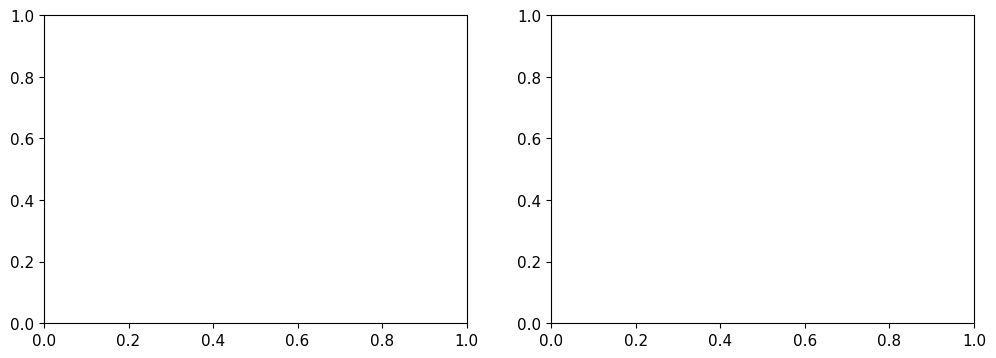

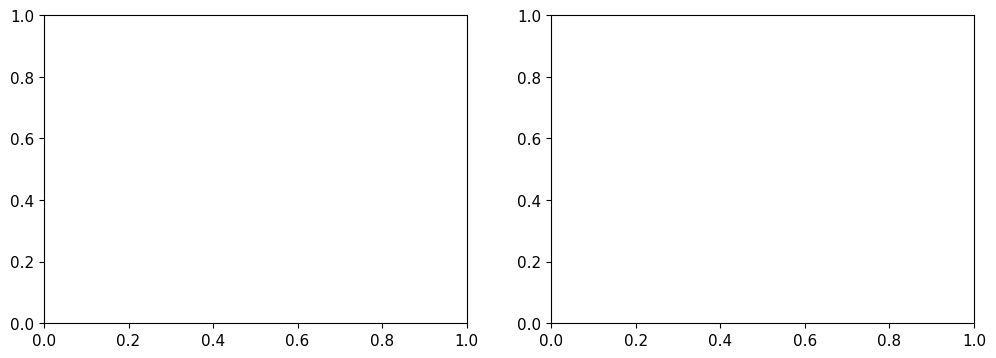

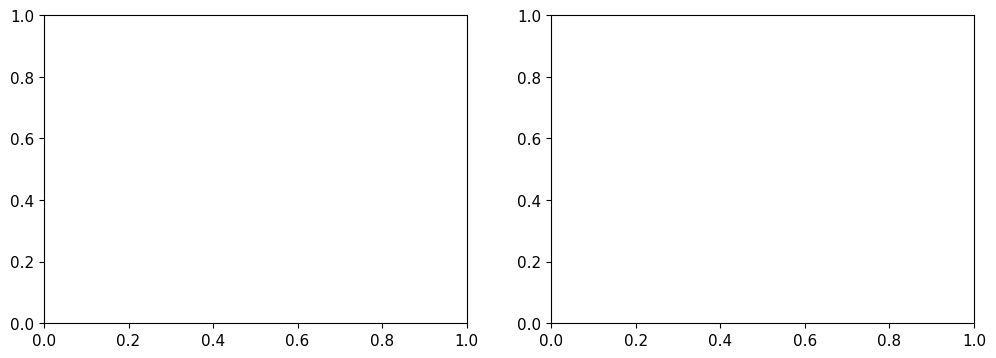

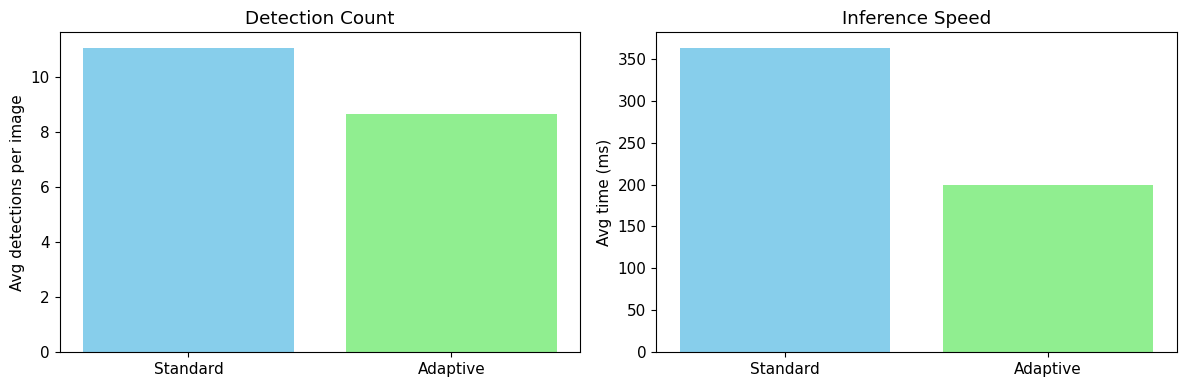

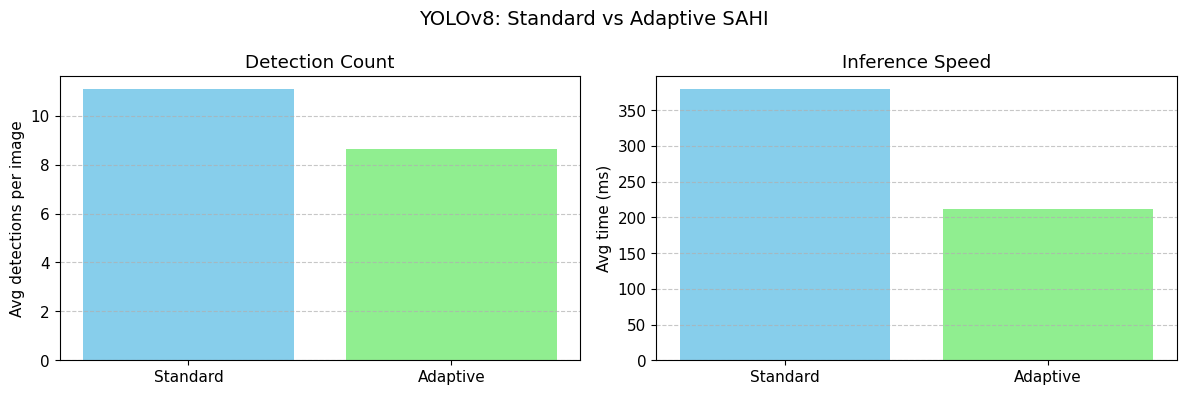

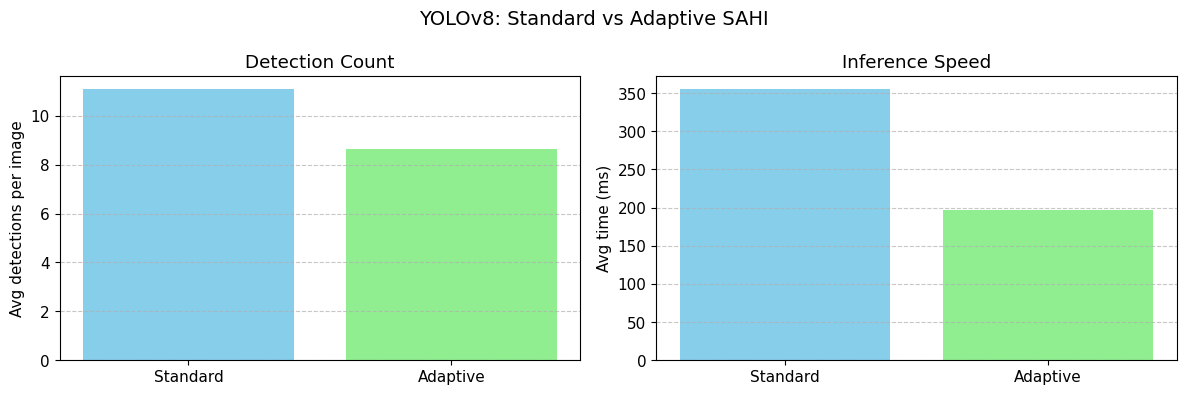

✅ Plot saved as sahi_comparison_v8.png
✅ Plot saved to Drive: /content/drive/MyDrive/DriveIndia/sahi_comparison_v8.png


<Figure size 640x480 with 0 Axes>

In [ ]:
%matplotlib inline

import matplotlib.pyplot as plt
import os

# ---- Plot ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Average detections
ax1.bar(['Standard', 'Adaptive'],
        [df_v8['std_dets'].mean(), df_v8['adapt_dets'].mean()],
        color=['skyblue', 'lightgreen'])
ax1.set_ylabel('Avg detections per image')
ax1.set_title('Detection Count')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Average time
ax2.bar(['Standard', 'Adaptive'],
        [df_v8['std_time_ms'].mean(), df_v8['adapt_time_ms'].mean()],
        color=['skyblue', 'lightgreen'])
ax2.set_ylabel('Avg time (ms)')
ax2.set_title('Inference Speed')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('YOLOv8: Standard vs Adaptive SAHI', fontsize=14)
plt.tight_layout()

# ---- Display and save ----
plt.show()

# Save to current directory
plt.savefig('sahi_comparison_v8.png', dpi=150, bbox_inches='tight')
print("✅ Plot saved as sahi_comparison_v8.png")

# Optionally save to Drive
drive_path = '/content/drive/MyDrive/DriveIndia/sahi_comparison_v8.png'
plt.savefig(drive_path, dpi=150, bbox_inches='tight')
print(f"✅ Plot saved to Drive: {drive_path}")

## Best SAHI config

In [ ]:
# ============================================================
# PARAMETER SWEEP: Square + Rectangular Slices (YOLOv8)
# ============================================================
import os, time
import pandas as pd
from tqdm import tqdm

TEST_IMAGE_DIR = '/content/drive/MyDrive/DriveIndia/images/test'
image_files = [f for f in os.listdir(TEST_IMAGE_DIR) if f.endswith(('.jpg','.png'))]

# Slice shapes (height, width)
slice_shapes = [
    (320, 320),
    (640, 640),
    (1024, 1024),
    (320, 640),
    (640, 320),
    (640, 1024),
    (1024, 640),
]

overlaps = [0.1, 0.2, 0.3]

results_sweep = []

for (slice_h, slice_w) in slice_shapes:
    for overlap in overlaps:
        print(f"\nTesting {slice_h}x{slice_w}, overlap={overlap:.1f}")
        total_dets = 0
        total_time = 0.0
        for img_file in tqdm(image_files, desc="Processing", leave=False):
            img_path = os.path.join(TEST_IMAGE_DIR, img_file)
            dets, t = run_standard_sahi_v8(sahi_model_v8, img_path,
                                           slice_h, slice_w, overlap)
            total_dets += len(dets)
            total_time += t
        avg_dets = total_dets / len(image_files)
        avg_time_ms = (total_time / len(image_files)) * 1000
        results_sweep.append({
            'slice_h': slice_h,
            'slice_w': slice_w,
            'overlap': overlap,
            'avg_dets': avg_dets,
            'avg_time_ms': avg_time_ms
        })

df_sweep = pd.DataFrame(results_sweep)
print("\n📊 Parameter Sweep Results (rectangular included):")
print(df_sweep.sort_values('avg_dets', ascending=False).to_string(index=False))
df_sweep.to_csv('sahi_param_sweep_rect.csv', index=False)
print("\n✅ Results saved to sahi_param_sweep_rect.csv")


Testing 320x320, overlap=0.1



Testing 320x320, overlap=0.2



Testing 320x320, overlap=0.3



Testing 640x640, overlap=0.1



Testing 640x640, overlap=0.2


...


Testing 640x1024, overlap=0.3



Testing 1024x640, overlap=0.1



Testing 1024x640, overlap=0.2



Testing 1024x640, overlap=0.3



📊 Parameter Sweep Results (rectangular included):
 slice_h  slice_w  overlap  avg_dets  avg_time_ms
     320      320      0.3     17.68  1274.142933
     320      320      0.1     15.44   950.095110
     320      320      0.2     15.22   919.149289
     320      640      0.3     15.06   443.263102
     640      320      0.3     14.04   402.959442
     320      640      0.2     13.70   370.146465
     320      640      0.1     13.40   356.794271
     640      320      0.2     12.88   370.825443
     640      320      0.1     12.82   355.904608
     640      640      0.3     11.26   350.363331
     640      640      0.2     11.08   336.071277
     640      640      0.1     10.92   328.348937
     640     1024      0.2      9.00   252.342029
     640     1024      0.3      8.94   253.087606
    1024      640      0.3      8.90   303.153996
    1024      640      0.1      8.76   290.204768
     640     1024      0.1      8.74   229.004474
    1024      640      0.2      8.68   292.725582

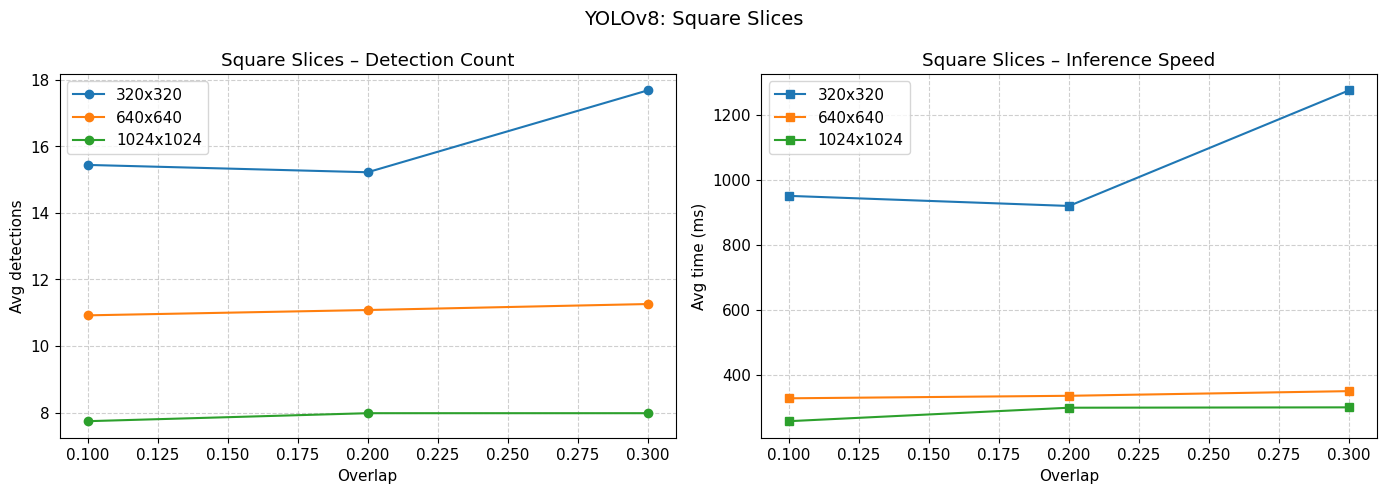

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

square_df = df_sweep[df_sweep['slice_h'] == df_sweep['slice_w']]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for slice_size in square_df['slice_h'].unique():
    subset = square_df[square_df['slice_h'] == slice_size].sort_values('overlap')
    label = f"{slice_size}x{slice_size}"
    ax1.plot(subset['overlap'], subset['avg_dets'], marker='o', label=label)
    ax2.plot(subset['overlap'], subset['avg_time_ms'], marker='s', label=label)

ax1.set_xlabel('Overlap'); ax1.set_ylabel('Avg detections')
ax1.set_title('Square Slices – Detection Count')
ax1.legend(); ax1.grid(True, linestyle='--', alpha=0.6)

ax2.set_xlabel('Overlap'); ax2.set_ylabel('Avg time (ms)')
ax2.set_title('Square Slices – Inference Speed')
ax2.legend(); ax2.grid(True, linestyle='--', alpha=0.6)

plt.suptitle('YOLOv8: Square Slices', fontsize=14)
plt.tight_layout()
plt.savefig('sahi_sweep_square.png', dpi=150)
plt.show()

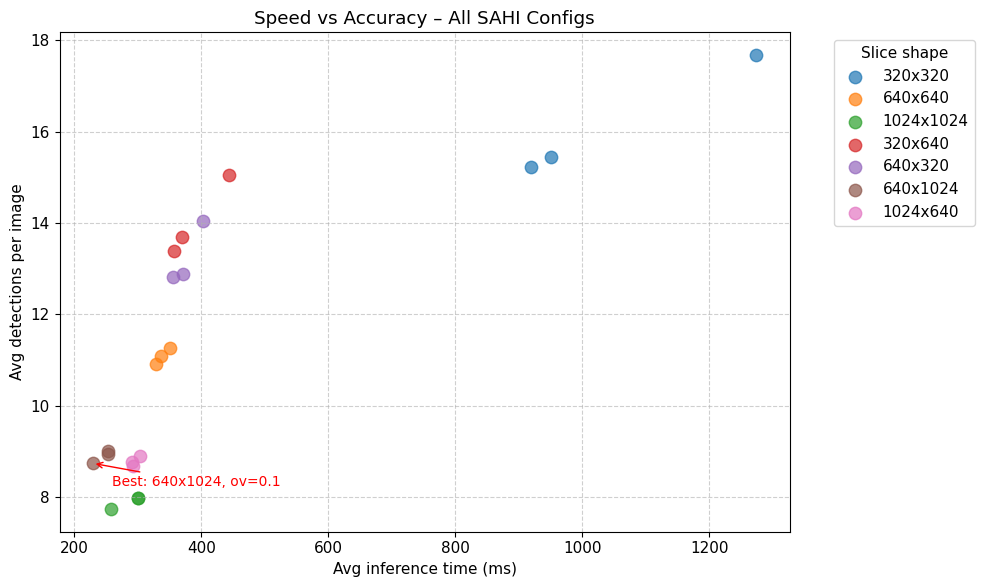

In [ ]:
plt.figure(figsize=(10, 6))

# Plot each shape with a different marker/color
for shape in df_sweep[['slice_h','slice_w']].drop_duplicates().values:
    h, w = shape
    subset = df_sweep[(df_sweep['slice_h']==h) & (df_sweep['slice_w']==w)]
    label = f"{h}x{w}"
    plt.scatter(subset['avg_time_ms'], subset['avg_dets'],
                label=label, s=80, alpha=0.7)

# Highlight best config
best_idx = (df_sweep['avg_dets'] / df_sweep['avg_time_ms']).idxmax()
best = df_sweep.loc[best_idx]
plt.annotate(f"Best: {int(best['slice_h'])}x{int(best['slice_w'])}, ov={best['overlap']:.1f}",
             xy=(best['avg_time_ms'], best['avg_dets']),
             xytext=(best['avg_time_ms']+30, best['avg_dets']-0.5),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=10, color='red')

plt.xlabel('Avg inference time (ms)')
plt.ylabel('Avg detections per image')
plt.title('Speed vs Accuracy – All SAHI Configs')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Slice shape')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('sahi_sweep_all.png', dpi=150, bbox_inches='tight')
plt.show()

In [1]:
top5 = df_sweep.sort_values('avg_dets', ascending=False).head(5)
print("\n🏆 Top 5 Configurations (by detection count):")
print(top5[['slice_h', 'slice_w', 'overlap', 'avg_dets', 'avg_time_ms']].to_string(index=False))

NameError: name 'df_sweep' is not defined

## Pre-existing work

In [ ]:
def build_sahi_model(model_path: str, conf: float = 0.25) -> AutoDetectionModel:
    """Load the trained YOLO model into SAHI."""
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    return AutoDetectionModel.from_pretrained(
        model_type            = 'yolov8',
        model_path            = model_path,
        confidence_threshold  = conf,
        device                = device,
    )


def compute_iou(box1, box2) -> float:
    x1 = max(box1[0], box2[0]); y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2]); y2 = min(box1[3], box2[3])
    inter  = max(0, x2-x1) * max(0, y2-y1)
    area1  = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2  = (box2[2]-box2[0]) * (box2[3]-box2[1])
    union  = area1 + area2 - inter
    return inter / union if union > 0 else 0.0


def run_vanilla_yolo(yolo_model, image_path: str,
                     conf: float = 0.25, iou: float = 0.50) -> list:
    """Run standard YOLO inference. Returns list of [x1,y1,x2,y2,score,cls]."""
    results = yolo_model(image_path, conf=conf, iou=iou)
    dets    = []
    if results[0].boxes is not None:
        for box in results[0].boxes:
            x1,y1,x2,y2 = box.xyxy[0].tolist()
            dets.append([x1, y1, x2, y2, float(box.conf[0]), int(box.cls[0])])
    return dets


def run_sahi_yolo(sahi_model, image_path: str,
                  slice_h: int = 640, slice_w: int = 640,
                  overlap: float = 0.2) -> list:
    """Run SAHI sliced inference. Returns list of [x1,y1,x2,y2,score,cls]."""
    result = get_sliced_prediction(
        image_path,
        sahi_model,
        slice_height              = slice_h,
        slice_width               = slice_w,
        overlap_height_ratio      = overlap,
        overlap_width_ratio       = overlap,
        postprocess_match_metric  = "IOU",
        postprocess_match_threshold = 0.5,
        verbose                   = 0,
    )
    dets = []
    for pred in result.object_prediction_list:
        bbox = pred.bbox.to_xyxy()
        dets.append([bbox[0], bbox[1], bbox[2], bbox[3],
                     pred.score.value, pred.category.id])
    return dets


print("✓ SAHI utilities ready")



In [ ]:
import glob
MODEL_CANDIDATES = [
    f'{EXPERIMENT_DIR}/yolov8m_driveindia/weights/best.pt',
    f'{ROOT_DIR}/yolov8m_driveindia/weights/best.pt',
    f'{ROOT_DIR}/best.pt',
]


MODEL_PATH = None
for candidate in MODEL_CANDIDATES:
    if os.path.exists(candidate):
        MODEL_PATH = candidate
        break
yolo_model = YOLO(MODEL_PATH)

def find_images(directory, max_count=20):
    imgs = []
    for ext in ('*.jpg', '*.jpeg', '*.png', '*.JPG'):
        imgs.extend(glob.glob(os.path.join(directory, ext)))
    return imgs[:max_count]

val_images   = find_images(VAL_IMAGE_DIR)


image_pool = val_images
pool_label = "val/"


if image_pool:
    print(f"\n Will use images from: {pool_label}  ({len(image_pool)} available)")
else:
    raise FileNotFoundError(
        "No images found anywhere under DriveIndia/. "
        "Check that Google Drive is mounted and the folder exists."
    )



In [ ]:
class KalmanBoxTracker:
    _count = 0

    @classmethod
    def reset_count(cls):
        cls._count = 0

    def __init__(self, bbox):
        KalmanBoxTracker._count += 1
        self.track_id          = KalmanBoxTracker._count
        self.hits              = 1
        self.hit_streak        = 1
        self.time_since_update = 0
        self.age               = 0

        self.kf = KalmanFilter(dim_x=7, dim_z=4)
        self.kf.F = np.array([
            [1,0,0,0,1,0,0],
            [0,1,0,0,0,1,0],
            [0,0,1,0,0,0,1],
            [0,0,0,1,0,0,0],
            [0,0,0,0,1,0,0],
            [0,0,0,0,0,1,0],
            [0,0,0,0,0,0,1],
        ], dtype=np.float32)
        self.kf.H        = np.eye(4, 7, dtype=np.float32)
        self.kf.R[2:,2:] *= 10.
        self.kf.P[4:,4:] *= 1000.
        self.kf.P        *= 10.
        self.kf.Q[-1,-1] *= 0.01
        self.kf.Q[4:,4:] *= 0.01

        x1,y1,x2,y2 = bbox
        cx = (x1+x2)/2; cy = (y1+y2)/2
        w  = x2-x1;     h  = y2-y1
        s  = w*h;        r  = w/float(h+1e-6)
        self.kf.x[:4] = [[cx],[cy],[s],[r]]

    @staticmethod
    def _to_xyxy(x):
        cx,cy,s,r = float(x[0]),float(x[1]),float(x[2]),float(x[3])
        s = max(s, 0)
        w = np.sqrt(s * abs(r)) if r > 0 else 0
        h = s / (w + 1e-6)
        return np.array([cx-w/2, cy-h/2, cx+w/2, cy+h/2])

    def predict(self):
        if self.kf.x[6] + self.kf.x[2] <= 0:
            self.kf.x[6] = 0.
        self.kf.predict()
        self.age               += 1
        self.time_since_update += 1
        if self.time_since_update > 0:
            self.hit_streak = 0
        return self._to_xyxy(self.kf.x)

    def update(self, bbox):
        x1,y1,x2,y2 = bbox
        cx=(x1+x2)/2; cy=(y1+y2)/2
        w=x2-x1; h=y2-y1
        s=w*h; r=w/float(h+1e-6)
        self.kf.update([[cx],[cy],[s],[r]])
        self.time_since_update = 0
        self.hits             += 1
        self.hit_streak       += 1

    def get_state(self):
        return self._to_xyxy(self.kf.x)


def _iou_batch(a, b):
    a = np.expand_dims(a, 1)
    b = np.expand_dims(b, 0)
    inter = (np.maximum(0, np.minimum(a[...,2],b[...,2]) - np.maximum(a[...,0],b[...,0])) *
             np.maximum(0, np.minimum(a[...,3],b[...,3]) - np.maximum(a[...,1],b[...,1])))
    area_a = (a[...,2]-a[...,0]) * (a[...,3]-a[...,1])
    area_b = (b[...,2]-b[...,0]) * (b[...,3]-b[...,1])
    return inter / np.where(area_a+area_b-inter == 0, 1e-9, area_a+area_b-inter)


class OCSort:
    def __init__(self, det_thresh=0.25, max_age=30, min_hits=1, iou_threshold=0.3):
        self.det_thresh    = det_thresh
        self.max_age       = max_age
        self.min_hits      = min_hits
        self.iou_threshold = iou_threshold
        self.trackers      = []
        self.frame_count   = 0
        KalmanBoxTracker.reset_count()

    def update(self, dets: np.ndarray) -> np.ndarray:
        self.frame_count += 1

        trk_preds, to_del = [], []
        for t, trk in enumerate(self.trackers):
            p = trk.predict()
            if np.any(np.isnan(p)):
                to_del.append(t)
            else:
                trk_preds.append(np.append(p, trk.track_id))
        for t in reversed(to_del):
            self.trackers.pop(t)

        trk_arr = np.array(trk_preds) if trk_preds else np.empty((0,5))

        if dets is None or len(dets) == 0:
            dets = np.empty((0,5))
        dets = dets[dets[:,4] >= self.det_thresh] if len(dets) > 0 else dets

        matched, unmatched_dets, unmatched_trks = [], list(range(len(dets))), []
        if len(dets) > 0 and len(trk_arr) > 0:
            iou_mat = _iou_batch(dets[:,:4], trk_arr[:,:4])
            r_idx, c_idx = linear_sum_assignment(-iou_mat)
            unmatched_dets = [d for d in range(len(dets)) if d not in r_idx]
            unmatched_trks = [t for t in range(len(trk_arr)) if t not in c_idx]
            for r,c in zip(r_idx, c_idx):
                if iou_mat[r,c] >= self.iou_threshold:
                    matched.append((r,c))
                else:
                    unmatched_dets.append(r)
                    unmatched_trks.append(c)

        for det_i, trk_i in matched:
            self.trackers[trk_i].update(dets[det_i,:4])

        for det_i in unmatched_dets:
            self.trackers.append(KalmanBoxTracker(dets[det_i,:4]))

        self.trackers = [t for t in self.trackers if t.time_since_update <= self.max_age]

        output = []
        for trk in self.trackers:
            if trk.time_since_update < 1 and trk.hits >= self.min_hits:
                output.append([*trk.get_state(), trk.track_id])

        return np.array(output, dtype=np.float32) if output else np.empty((0,5))

In [ ]:
class PerClassOCSort:
    """Runs one OCSort tracker per class so IDs don't mix across classes."""
    def __init__(self, n_classes, **kwargs):
        self.trackers = {i: OCSort(**kwargs) for i in range(n_classes)}

    def reset(self):
        for t in self.trackers.values():
            t.__init__(t.det_thresh, t.max_age, t.min_hits, t.iou_threshold)
            t.frame_count = 0
            t.trackers    = []
            KalmanBoxTracker.reset_count()

    def update(self, dets_with_cls: list) -> list:
        """
        dets_with_cls: list of [x1,y1,x2,y2, score, class_id]
        Returns: list of dicts {track_id, bbox, class_id, class_name}
        """
        by_class = defaultdict(list)
        for d in dets_with_cls:
            by_class[int(d[5])].append(d)

        results = []
        for cls_id, cls_dets in by_class.items():
            if cls_id not in self.trackers:
                continue
            arr = np.array([[d[0],d[1],d[2],d[3],d[4]] for d in cls_dets],
                           dtype=np.float32)
            tracked = self.trackers[cls_id].update(arr)
            for row in tracked:
                x1,y1,x2,y2,tid = row
                results.append({
                    'track_id'  : int(tid),
                    'bbox'      : [int(x1),int(y1),int(x2),int(y2)],
                    'class_id'  : cls_id,
                    'class_name': CLASS_NAMES[cls_id] if cls_id < len(CLASS_NAMES) else str(cls_id),
                    'score'     : float([d[4] for d in cls_dets][0]),
                })
        return results


ocsort = PerClassOCSort(
    n_classes     = len(CLASS_NAMES),
    det_thresh    = 0.25,
    max_age       = 30,
    min_hits      = 1,
    iou_threshold = 0.30,
)


In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
sahi_model = AutoDetectionModel.from_pretrained(
    model_type           = 'yolov8',
    model_path           = MODEL_PATH,
    confidence_threshold = 0.40,
    device               = device,
)

PALETTE = [
    (220, 50,  50 ), (50,  150, 220), (50,  200, 100), (220, 150, 50 ),
    (150, 50,  220), (50,  220, 200), (220, 100, 150), (100, 220, 50 ),
    (50,  50,  220), (220, 220, 50 ), (100, 50,  150), (50,  150, 100),
    (200, 100, 50 ), (50,  100, 200), (150, 200, 50 ), (200, 50,  150),
    (100, 200, 150), (150, 100, 200), (200, 150, 100), (100, 150, 200),
    (50,  200, 150), (200, 50,  100), (150, 50,  100), (100, 50,  200),
]

def _color(cls_id):
    return PALETTE[cls_id % len(PALETTE)]

def _draw(img_rgb, x1,y1,x2,y2, cls_id, label, thick=2):
    c   = _color(cls_id)
    bgr = (c[2], c[1], c[0])
    x1,y1,x2,y2 = int(x1),int(y1),int(x2),int(y2)
    cv2.rectangle(img_rgb, (x1,y1), (x2,y2), c, thick)
    (tw,th),_ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.42, 1)
    cv2.rectangle(img_rgb, (x1, y1-th-6), (x1+tw+3, y1), c, -1)
    cv2.putText(img_rgb, label, (x1+2, y1-4),
                cv2.FONT_HERSHEY_SIMPLEX, 0.42, (255,255,255), 1, cv2.LINE_AA)

def _iou(a,b):
    x1=max(a[0],b[0]); y1=max(a[1],b[1])
    x2=min(a[2],b[2]); y2=min(a[3],b[3])
    inter=max(0,x2-x1)*max(0,y2-y1)
    ua=(a[2]-a[0])*(a[3]-a[1]); ub=(b[2]-b[0])*(b[3]-b[1])
    return inter/(ua+ub-inter+1e-9)



In [ ]:
LARGE_CLASS_IDS = {
    2,   # Car
    4,   # Bus
    6,   # Truck
    8,   # Ambulance
    9,   # Police vehicle
    10,  # Tractor
    12,  # Construction vehicle
    16,  # Temporary traffic barrier
    18,  # Rumblestrips
    19,  # Unmarked speed bump
    20,  # Marked speed bump
    21,  # Zebra crossing
}

# Small objects — SAHI slicing actually helps these
SMALL_CLASS_IDS_SAHI = {
    0,   # Person
    1,   # Bicycle
    3,   # Motorcycle
    5,   # Commercial vehicle
    7,   # Autorickshaw
    11,  # Pushcart
    13,  # Route board
    14,  # Traffic sign
    15,  # Traffic light
    17,  # Traffic cone
    22,  # Animal
    23,  # Pothole
}


def _nms(dets: list, iou_threshold: float = 0.50) -> list:
    if not dets:
        return []
    by_class = defaultdict(list)
    for d in dets:
        by_class[int(d[5])].append(d)
    kept = []
    for cls_id, cls_dets in by_class.items():
        cls_dets = sorted(cls_dets, key=lambda x: -x[4])
        suppressed = [False] * len(cls_dets)
        for i in range(len(cls_dets)):
            if suppressed[i]:
                continue
            kept.append(cls_dets[i])
            for j in range(i + 1, len(cls_dets)):
                if not suppressed[j] and _iou(cls_dets[i][:4], cls_dets[j][:4]) > iou_threshold:
                    suppressed[j] = True
    return kept


def run_hybrid_inference(image_path):

    v_results = yolo_model(image_path, conf=0.35, iou=0.50, verbose=False)
    vanilla_dets = []
    if v_results[0].boxes is not None:
        for b in v_results[0].boxes:
            x1, y1, x2, y2 = b.xyxy[0].tolist()
            vanilla_dets.append(
                [x1, y1, x2, y2, float(b.conf[0]), int(b.cls[0])]
            )

    large_dets = [d for d in vanilla_dets if int(d[5]) in LARGE_CLASS_IDS]

    try:
        sahi_res = get_sliced_prediction(
            image_path,
            sahi_model,
            slice_height                = 640,
            slice_width                 = 640,
            overlap_height_ratio        = 0.10,
            overlap_width_ratio         = 0.10,
            postprocess_match_metric    = "IOU",
            postprocess_match_threshold = 0.60,
            verbose                     = 0,
        )
        sahi_dets = []
        for pred in sahi_res.object_prediction_list:
            if pred.score.value < 0.40:
                continue
            bb = pred.bbox.to_xyxy()
            cls = pred.category.id
            if cls in SMALL_CLASS_IDS_SAHI:
                sahi_dets.append(
                    [bb[0], bb[1], bb[2], bb[3], pred.score.value, cls]
                )
    except Exception as e:
        print(f"  [WARN] SAHI failed: {e} — using vanilla for all classes")
        sahi_dets = [d for d in vanilla_dets if int(d[5]) in SMALL_CLASS_IDS_SAHI]

    merged = _nms(large_dets + sahi_dets, iou_threshold=0.50)

    return vanilla_dets, sahi_dets, large_dets, merged



In [ ]:
def full_comparison(image_path, save_path=None):
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print(f"[ERROR] Cannot open: {image_path}")
        return
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    H, W    = img_bgr.shape[:2]
    fname   = os.path.basename(image_path)

    print(f"\n{'─'*60}")
    print(f"  {fname}  ({W}×{H})")
    print(f"{'─'*60}")

    print("  [1/3] Hybrid inference …", end="  ", flush=True)
    vanilla_dets, sahi_dets, large_dets, merged_dets = run_hybrid_inference(image_path)
    print(
        f"vanilla={len(vanilla_dets)}  "
        f"large(vanilla)={len(large_dets)}  "
        f"small(SAHI)={len(sahi_dets)}  "
        f"merged={len(merged_dets)}"
    )

    print("  [2/3] OC-SORT …", end="  ", flush=True)
    ocsort.reset()
    tracked = ocsort.update(merged_dets)
    print(f"{len(tracked)} track IDs assigned")

    def _is_new(d):
        return not any(_iou(d[:4], v[:4]) > 0.45 for v in vanilla_dets)
    new_dets = [d for d in merged_dets if _is_new(d)]
    print(f"  [3/3] SAHI found {len(new_dets)} extra detections vs vanilla")

    p1 = img_rgb.copy()
    for d in vanilla_dets:
        x1, y1, x2, y2, sc, cls = d
        cls  = int(cls)
        name = CLASS_NAMES[cls] if cls < len(CLASS_NAMES) else str(cls)
        _draw(p1, x1, y1, x2, y2, cls, f"{name} {sc:.2f}")

    p2 = img_rgb.copy()
    for d in merged_dets:
        x1, y1, x2, y2, sc, cls = d
        cls  = int(cls)
        name = CLASS_NAMES[cls] if cls < len(CLASS_NAMES) else str(cls)
        if _is_new(d):
            cv2.rectangle(p2,
                          (int(x1)-2, int(y1)-2),
                          (int(x2)+2, int(y2)+2),
                          (255, 220, 0), 4)
            _draw(p2, x1, y1, x2, y2, cls, f"NEW {name} {sc:.2f}", thick=2)
        else:
            _draw(p2, x1, y1, x2, y2, cls, f"{name} {sc:.2f}")

    p3 = img_rgb.copy()
    for obj in tracked:
        x1, y1, x2, y2 = obj['bbox']
        cls  = obj['class_id']
        tid  = obj['track_id']
        name = obj['class_name']
        _draw(p3, x1, y1, x2, y2, cls, f"#{tid} {name}", thick=2)

    v_by_cls = defaultdict(int)
    m_by_cls = defaultdict(int)
    for d in vanilla_dets: v_by_cls[int(d[5])] += 1
    for d in merged_dets:  m_by_cls[int(d[5])] += 1
    active_cls = sorted(set(v_by_cls) | set(m_by_cls))

    rows = [("Class", "Vanilla", "Hybrid", "Δ", "Via")]
    for cid in active_cls:
        name  = (CLASS_NAMES[cid] if cid < len(CLASS_NAMES) else str(cid))[:16]
        v_cnt = v_by_cls.get(cid, 0)
        m_cnt = m_by_cls.get(cid, 0)
        delta = m_cnt - v_cnt
        d_str = f"+{delta}" if delta > 0 else str(delta)
        via   = "SAHI" if cid in SMALL_CLASS_IDS_SAHI else "Vanilla"
        rows.append((name, str(v_cnt), str(m_cnt), d_str, via))
    rows.append((
        "TOTAL",
        str(len(vanilla_dets)),
        str(len(merged_dets)),
        f"+{len(new_dets)}" if new_dets else "0",
        ""
    ))

    col_w = [max(len(r[i]) for r in rows) for i in range(5)]
    sep   = "┼".join("─" * (w + 2) for w in col_w)

    def fmt(row):
        return "│".join(f" {row[i]:<{col_w[i]}} " for i in range(5))

    stats_lines  = ["┌" + sep.replace("┼", "┬") + "┐"]
    stats_lines += ["│" + fmt(rows[0]) + "│"]
    stats_lines += ["├" + sep + "┤"]
    for row in rows[1:-1]:
        stats_lines += ["│" + fmt(row) + "│"]
    stats_lines += ["├" + sep + "┤"]
    stats_lines += ["│" + fmt(rows[-1]) + "│"]
    stats_lines += ["└" + sep.replace("┼", "┴") + "┘"]
    stats_lines += [
        "",
        "  Large classes → Vanilla YOLO (conf ≥ 0.35)",
        "  Small classes → SAHI (conf ≥ 0.40, overlap=0.10)",
        f"  OC-SORT: {len(tracked)} track IDs assigned",
        "",
        "  Yellow border = SAHI-only detection",
        f"  {len(new_dets)} extra detections vs vanilla",
    ]
    stats_text = "\n".join(stats_lines)

    legend_patches = [
        mpatches.Patch(
            color=tuple(c / 255 for c in _color(cid)),
            label=(
                f"{cid}: "
                f"{CLASS_NAMES[cid] if cid < len(CLASS_NAMES) else str(cid)}"
                f" [{'S' if cid in SMALL_CLASS_IDS_SAHI else 'L'}]"
            )
        )
        for cid in active_cls
    ]

    fig, axes = plt.subplots(2, 2, figsize=(26, 14))
    fig.patch.set_facecolor('#1a1a2e')
    fig.suptitle(
        f"DriveIndia Hybrid  ·  {fname}  ({W}×{H})\n"
        "[L] Vanilla YOLO   [S] SAHI sliced",
        fontsize=13, fontweight='bold', color='white', y=0.99
    )

    panel_info = [
        (axes[0, 0], p1,
         f"① Vanilla YOLOv8m (all classes)\n{len(vanilla_dets)} detections  conf≥0.35",
         '#e8e8e8'),
        (axes[0, 1], p2,
         f"② Hybrid: [L] Vanilla + [S] SAHI\n"
         f"{len(merged_dets)} detections  (+{len(new_dets)} new in yellow)",
         '#ffd700'),
        (axes[1, 0], p3,
         f"③ OC-SORT track IDs  (from hybrid)\n"
         f"{len(tracked)} IDs  ·  colour = class",
         '#7ec8e3'),
    ]

    for ax, img, title, tc in panel_info:
        ax.imshow(img)
        ax.set_title(title, fontsize=11, fontweight='bold', color=tc, pad=6)
        ax.axis('off')
        for spine in ax.spines.values():
            spine.set_edgecolor('#444')

    ax4 = axes[1, 1]
    ax4.set_facecolor('#0f0f1a')
    ax4.axis('off')
    ax4.set_title(
        "④ Detection Stats & Class Legend  [S]=SAHI  [L]=Vanilla",
        fontsize=11, fontweight='bold', color='#e8e8e8', pad=6
    )
    ax4.text(
        0.02, 0.97, stats_text,
        transform=ax4.transAxes,
        fontsize=8.5, verticalalignment='top',
        fontfamily='monospace', color='#d0d0d0',
        bbox=dict(boxstyle='round', facecolor='#111122',
                  edgecolor='#444', alpha=0.95),
    )
    ax4.legend(
        handles=legend_patches, loc='lower left',
        fontsize=8, title='Classes in image', title_fontsize=9,
        framealpha=0.85, ncol=2,
        labelcolor='white', facecolor='#111122', edgecolor='#555',
    )

    plt.tight_layout(rect=[0, 0, 1, 0.97])

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight',
                    facecolor=fig.get_facecolor())
        print(f"  ✓ Saved → {save_path}")

    plt.show()
    print(stats_text)
    return vanilla_dets, sahi_dets, tracked

In [ ]:
import matplotlib.patches as mpatches
PREFERRED = [
      f'{VAL_IMAGE_DIR}/F_11_8_290.jpg',
      f'{VAL_IMAGE_DIR}/F_7_5_1642.jpg',
      f'{VAL_IMAGE_DIR}/F_8_6_914.jpg',
]
to_test = [p for p in PREFERRED if os.path.exists(p)]

remaining = [p for p in image_pool if p not in to_test]
random.seed(42)
random.shuffle(remaining)
to_test += remaining[: max(0, 3 - len(to_test))]

print(f"Images to process: {[os.path.basename(p) for p in to_test]}\n")

for img_path in to_test:
    out_name = os.path.splitext(os.path.basename(img_path))[0] + '_analysis.png'
    full_comparison(
        image_path = img_path,
        save_path  = os.path.join(TRACKING_DIR, out_name),
    )

print(f"Figures saved to: {TRACKING_DIR}")